In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL']='3'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import tensorflow as tf
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
tf.random.set_seed(42)

In [2]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year', 'Origin']
dataset = pd.read_csv(url, names=column_names, na_values="?", comment="\t", sep=" ", skipinitialspace=True)
dataset = dataset.dropna()
dataset_tf = tf.convert_to_tensor(dataset, dtype=tf.float32)
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,1


In [3]:
dataset_shuffled = tf.random.shuffle(dataset_tf, seed=22)
train_data, test_data = dataset_shuffled[100:], dataset_shuffled[:100]
x_train, y_train = train_data[:, 1:], train_data[:, 0]
x_test, y_test = test_data[:, 1:], test_data[:, 0]

In [4]:
def onehot_origin(x):
    origin = tf.cast(x[:, -1], tf.int32)
    origin_oh =tf.one_hot(origin - 1, depth=3)
    x_ohe = tf.concat([x[:, :-1], origin_oh], axis=1)
    return x_ohe

x_train_ohe, x_test_ohe = onehot_origin(x_train), onehot_origin(x_test)
x_train_ohe.numpy()

array([[  6., 232., 100., ...,   1.,   0.,   0.],
       [  4.,  98.,  90., ...,   0.,   1.,   0.],
       [  6., 200.,  88., ...,   1.,   0.,   0.],
       ...,
       [  8., 302., 129., ...,   1.,   0.,   0.],
       [  4.,  97.,  52., ...,   0.,   1.,   0.],
       [  6., 232., 100., ...,   1.,   0.,   0.]],
      shape=(292, 9), dtype=float32)

In [5]:
class Normalize(tf.Module):
    def __init__(self, x):
        super().__init__()
        self.mean = tf.math.reduce_mean(x, axis=0)
        self.std = tf.math.reduce_std(x, axis=0)

    def norm(self, x):
        return (x - self.mean) / self.std

    def unnorm(self, x):
        return x * self.std + self.mean

In [6]:
norm_x = Normalize(x_train_ohe)
norm_y = Normalize(y_train)
x_train_norm, y_train_norm = norm_x.norm(x_train_ohe), norm_y.norm(y_train)
x_test_norm, y_test_norm = norm_x.norm(x_test_ohe), norm_y.norm(y_test)

In [7]:
class LinearRegression(tf.Module):
    def __init__(self):
        super().__init__()
        self.built = False

    @tf.function
    def __call__(self, x):
        if not self.built:
            rand_w = tf.random.uniform(shape=[x.shape[-1], 1])
            rand_b = tf.random.uniform(shape=[])
            self.w = tf.Variable(rand_w)
            self.b = tf.Variable(rand_b)
            self.built = True
        y = tf.add(tf.matmul(x, self.w), self.b)
        return tf.squeeze(y, axis=1)

In [8]:
lin_reg = LinearRegression()
prediction = lin_reg(x_train_norm[:1])
prediction_unnorm = norm_y.unnorm(prediction)
prediction_unnorm.numpy()

array([11.909512], dtype=float32)

In [9]:
batch_size = 64
train_dataset = tf.data.Dataset.from_tensor_slices((x_train_norm, y_train_norm))
train_dataset = train_dataset.shuffle(buffer_size=x_train.shape[0]).batch(batch_size=batch_size)
test_dataset = tf.data.Dataset.from_tensor_slices((x_test_norm, y_test_norm))
test_dataset = test_dataset.shuffle(buffer_size=x_test.shape[0]).batch(batch_size=batch_size)

In [10]:
def mse_loss(y_pred, y):
    return tf.reduce_mean(tf.square(y_pred - y))

In [11]:
epochs = 100
learning_rate = 0.01
train_losses, test_losses = [], []
for epoch in range(epochs):
    batch_lossees_train, batch_lossees_test = [], []
    for x_batch, y_batch in train_dataset:
        with tf.GradientTape() as tape:
            y_pred_batch = lin_reg(x_batch)
            batch_loss = mse_loss(y_pred_batch, y_batch)
        grads = tape.gradient(batch_loss, lin_reg.variables)
        for g, v in zip(grads, lin_reg.variables):
            v.assign_sub(learning_rate * g)
        batch_lossees_train.append(batch_loss)
    for x_batch, y_batch in test_dataset:
        y_pred_batch = lin_reg(x_batch)
        batch_loss = mse_loss(y_pred_batch, y_batch)
        batch_lossees_test.append(batch_loss)
    train_loss = tf.reduce_mean(batch_lossees_train)
    test_loss = tf.reduce_mean(batch_lossees_test)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    if epoch % 10 == 0:
        print(f"Mean squared error for step {epoch} : {train_loss.numpy():.4f}")
print(f"\nFinal train loss: {train_loss:.4f}")
print(f"Final test loss: {test_loss:.4f}")

Mean squared error for step 0 : 5.1591
Mean squared error for step 10 : 0.6559
Mean squared error for step 20 : 0.3273
Mean squared error for step 30 : 0.2122
Mean squared error for step 40 : 0.1841
Mean squared error for step 50 : 0.1757
Mean squared error for step 60 : 0.1681
Mean squared error for step 70 : 0.1722
Mean squared error for step 80 : 0.1764
Mean squared error for step 90 : 0.1811

Final train loss: 0.1749
Final test loss: 0.1956


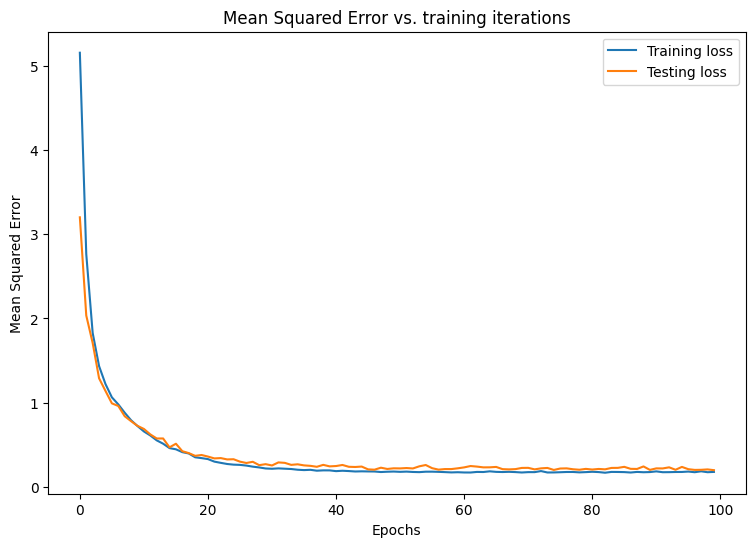

In [12]:
matplotlib.rcParams["figure.figsize"] = [9, 6]
plt.plot(range(epochs), train_losses, label="Training loss")
plt.plot(range(epochs), test_losses, label="Testing loss")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.title("Mean Squared Error vs. training iterations")
plt.show()

In [13]:
class ExportModule(tf.Module):
    def __init__(self, model, extract_features, norm_x, norm_y):
        super().__init__()
        self.model = model
        self.extract_features = extract_features
        self.norm_x = norm_x
        self.norm_y = norm_y

    @tf.function(input_signature=[tf.TensorSpec(shape=[None, None], dtype=tf.float32)])
    def __call__(self, x):
        x = self.extract_features(x)
        x = self.norm_x.norm(x)
        y = self.model(x)
        y = self.norm_y.unnorm(y)
        return y

In [15]:
lin_reg_export = ExportModule(model=lin_reg,
                              extract_features=onehot_origin,
                              norm_x=norm_x,
                              norm_y=norm_y)

In [16]:
import tempfile

models = tempfile.mkdtemp()
save_path = os.path.join(models, "lin_reg_export")
tf.saved_model.save(lin_reg_export, save_path)

INFO:tensorflow:Assets written to: /tmp/tmpdav_2a4y/lin_reg_export/assets


INFO:tensorflow:Assets written to: /tmp/tmpdav_2a4y/lin_reg_export/assets


In [17]:
lin_reg_loaded = tf.saved_model.load(save_path)
test_preds = lin_reg_loaded(x_test)
test_preds[:10].numpy()

array([28.85603 , 32.946976, 28.337957, 33.8785  , 23.166735, 11.922071,
       29.273775, 26.833492, 20.050072, 23.073439], dtype=float32)